# Statistcal Analysis:

## 1. Cha-square Test:

In [1]:
# import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# load the dataset of titanic:
df= sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# create a contigencency table:
contingency_table= pd.crosstab(df['sex'], df['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [4]:
# perform chi-square test:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")

Chi-square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58
Degrees of Freedom: 1
Expected Frequencies:


---

# 2. Normal Distribution Test:

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

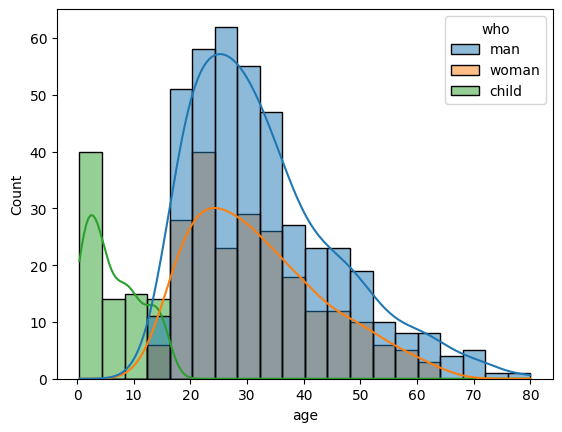

In [6]:
# graphical representation of age distribution
sns.histplot(data=df, x='age', kde=True,hue='who')

## Alterenative Hypotesis:


In [7]:
# shipero wilk test:
statistic, p_value = stats.shapiro(df['age'].dropna())
# print the statistic and p-value
print(f"Shapiro-Wilk Statistic: {statistic}")
print(f"P-value: {p_value}")
# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is normally distributed")
else:
    print("Reject the null hypothesis: Data is not normally distributed")

Shapiro-Wilk Statistic: 0.9814577414504954
P-value: 7.337348958673592e-08
Reject the null hypothesis: Data is not normally distributed


<Axes: xlabel='fare', ylabel='Count'>

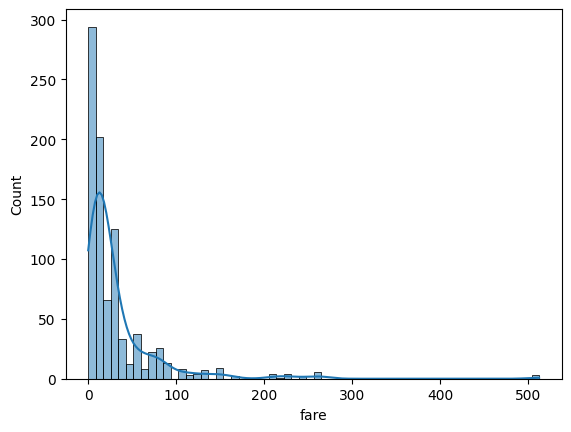

In [8]:
sns.histplot(data=df, x='fare', kde=True)

---

# t-test:

In [9]:
# simple data:
x=[1,2,3,4,5]

# known population mean:
mu=3
# perform one sample t-test:
t_statistic, p_value = stats.ttest_1samp(x, mu)

# print the t-statistic and p-value
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# print the results using if else statement: 
alpha = 0.05 
if p_value > alpha:
    print("Fail to reject the null hypothesis: Sample mean is equal to population mean")
else:
    print("Reject the null hypothesis: Sample mean is not equal to population mean")

T-statistic: 0.0
P-value: 1.0
Fail to reject the null hypothesis: Sample mean is equal to population mean


2. Two Sample T-test (independed)
   

In [10]:
# two sample t-test (independed)
group1 = [5, 6, 7, 8, 9]
group2 = [10, 11, 12, 13, 14]

# perform two sample t-test:
t_statistic, p_value = stats.ttest_ind(group1, group2)

# print the t-statistic and p-value
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}") 

# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: group1 means of both groups are equal")
else:
    print("Reject the null hypothesis: group2 means of both groups are not equal")


T-statistic: -5.0
P-value: 0.001052825793366539
Reject the null hypothesis: group2 means of both groups are not equal


---


# ANOVA
Anslysis of Variance:

# 1. one-way ANOVA

In [11]:
# sample data for ANOVA:

a=[5, 6, 7, 8, 9]
b=[10, 11, 12, 13, 14, 15, 16]
c=[15, 16, 17, 18, 19, 20] 

# perform one-way ANOVA:
f_statistic, p_value = stats.f_oneway(a, b, c)

# print the F-statistic and p-value
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: All group means are equal")
else:
    print("Reject the null hypothesis: At least one group mean is different")

F-statistic: 40.67567567567568
P-value: 8.744819848061139e-07
Reject the null hypothesis: At least one group mean is different


---

In [12]:
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

# MANVA:

In [13]:
# Load dataset
data = {
    'Method': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'MathScore': [85, 90, 88, 78, 82, 80, 92, 95, 94],
    'ScienceScore': [80, 85, 83, 75, 78, 77, 90, 92, 91]
}

df = pd.DataFrame(data)

print(df.head(10))

# Perform MANOVA
manova  = MANOVA.from_formula('MathScore + ScienceScore ~ Method', data=df)
print(manova.mv_test())

  Method  MathScore  ScienceScore
0      A         85            80
1      A         90            85
2      A         88            83
3      B         78            75
4      B         82            78
5      B         80            77
6      C         92            90
7      C         95            92
8      C         94            91
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0009 2.0000 5.0000 2827.6776 0.0000
         Pillai's trace    0.9991 2.0000 5.0000 2827.6776 0.0000
 Hotelling-Lawley trace 1131.0710 2.0000 5.0000 2827.6776 0.0000
    Roy's greatest root 1131.0710 2.0000 5.0000 2827.6776 0.0000
----------------------------------------------------------------
                              

---

# case study for statistcal Methods:

# Chi-squared Test:

In [14]:
import numpy as np
from scipy.stats import chisquare

In [15]:
# hypothetical observed frequencies:
observed_frequencies = np.array([50, 30])

# expected frequences (assuming a 50-50 distribution):
total_meals = observed_frequencies.sum()
expected_frequencies = np.array([total_meals * 0.5, total_meals * 0.5])

#perform chi-square goodness of fit test: 
chi2_statistic, p_value = chisquare(observed_frequencies, f_exp=expected_frequencies)                            

# print the chi-square statistic and p-value
print(f"Chi-square Statistic: {chi2_statistic}")
print(f"P-value: {p_value}")

# print the results using if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: Observed frequencies fit the expected distribution")
else:
    print("Reject the null hypothesis: Observed frequencies do not fit the expected distribution")

Chi-square Statistic: 5.0
P-value: 0.025347318677468325
Reject the null hypothesis: Observed frequencies do not fit the expected distribution


---

# t- test:

### one simple t-test:

In [16]:
# dataset  of tipe  is load:
df = sns.load_dataset('tips')
df.head() 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='Count'>

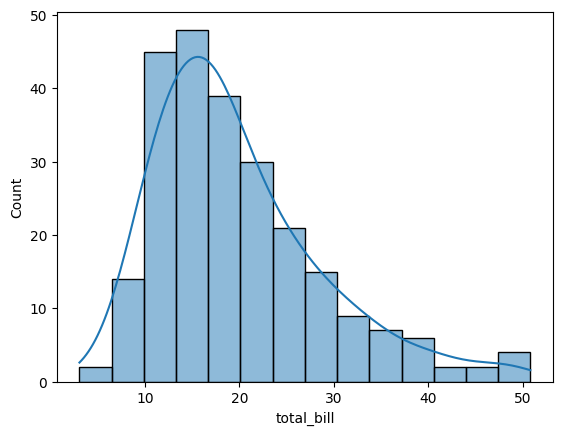

In [17]:
# graphical representation of total bill distribution
sns.histplot(data=df, x='total_bill', kde=True)

In [18]:
# shipero wilk test for total bill:
statistic, p_value = stats.shapiro(df['total_bill'])
# print the statistic and p-value
print(f"Shapiro-Wilk Statistic: {statistic}")
print(f"P-value: {p_value}")

#print the results of p-value on if else statement:
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is normally distributed")
else:
    print("Reject the null hypothesis: Data is not normally distributed")

Shapiro-Wilk Statistic: 0.9197187941346584
P-value: 3.324539186809091e-10
Reject the null hypothesis: Data is not normally distributed


In [19]:
# dataset load
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### one-way ANOVA:

In [24]:
# ANOVA test to compare age and class:
anova_result = stats.f_oneway(
    df[df['class'] == 'First']['age'].dropna(),
    df[df['class'] == 'Second']['age'].dropna(),
    df[df['class'] == 'Third']['age'].dropna()
)
print(f"ANOVA F-statistic: {anova_result.statistic}")
print(f"ANOVA P-value: {anova_result.pvalue}")

# print the results using if else statement:
alpha = 0.05
if anova_result.pvalue > alpha:
    print(f"Fail to reject the null hypothesis {anova_result.pvalue }: All group means are equal")
else:
    print(f"Reject the null hypothesis {anova_result.pvalue }: At least one group mean is different")

ANOVA F-statistic: 57.44348434067624
ANOVA P-value: 7.487984171959212e-24
Reject the null hypothesis 7.487984171959212e-24: At least one group mean is different


<Axes: xlabel='age', ylabel='Count'>

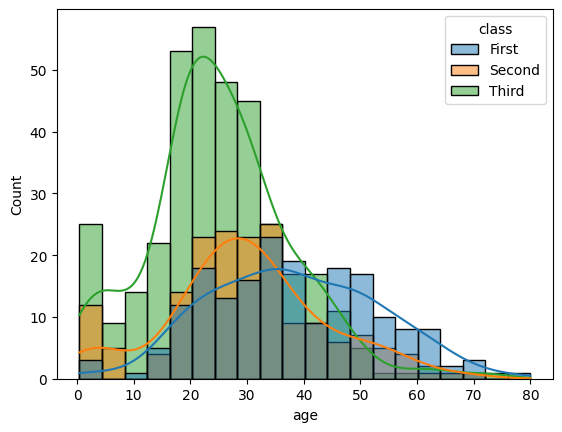

In [ ]:
# graphical representation of age distribution by class:
sns.histplot(data=df, x='age', kde=True,hue=' class')

In [32]:
# tukey HSD pairwise comparison:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(df['age'], df['sex'] + df['who'],alpha=0.05)
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1      group2   meandiff p-adj lower upper reject
---------------------------------------------------------
femalechild femalewoman      nan   nan   nan   nan  False
femalechild   malechild  -1.7426   nan   nan   nan  False
femalechild     maleman      nan   nan   nan   nan  False
femalewoman   malechild      nan   nan   nan   nan  False
femalewoman     maleman      nan   nan   nan   nan  False
  malechild     maleman      nan   nan   nan   nan  False
---------------------------------------------------------


<Axes: xlabel='who', ylabel='age'>

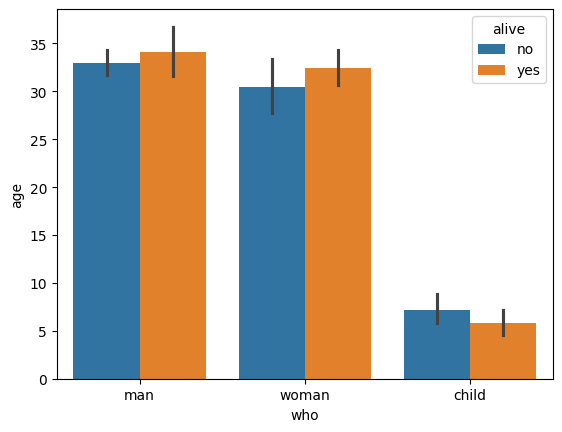

In [35]:
sns.barplot(data = df, x='who', y='age',hue='alive')

---

:

# correlation: 

<Axes: >

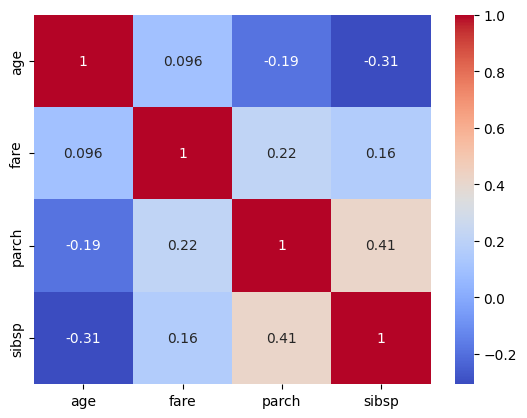

In [37]:
# create a graph of heatmap of correlation:

sns.heatmap(df[['age', 'fare', 'parch', 'sibsp']].corr(), annot=True, cmap='coolwarm')


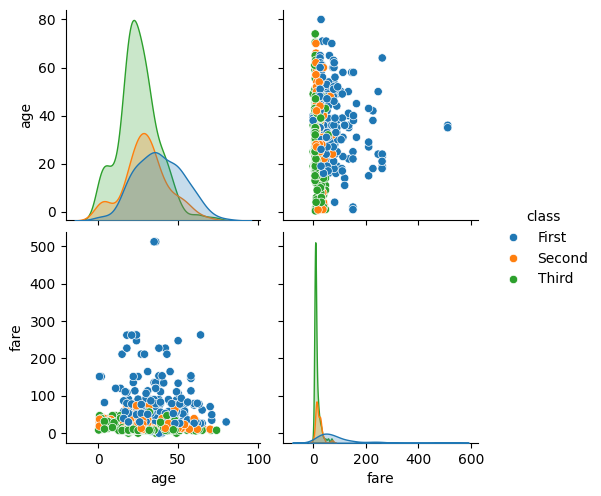

In [38]:
sns.pairplot(data=df, vars=['age', 'fare'], hue='class')

---